In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import os

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
# load data
df_all = pd.read_csv('../outputs/cleaned_text_data.csv')
df = df_all[df_all['file_type'] != 'interview']

# word cloud

In [4]:
option2_text = ' '.join(df[df['religious_group'] == 'option2']['cleaned_content'].dropna())
option1_text = ' '.join(df[df['religious_group'] == 'option1']['cleaned_content'].dropna())

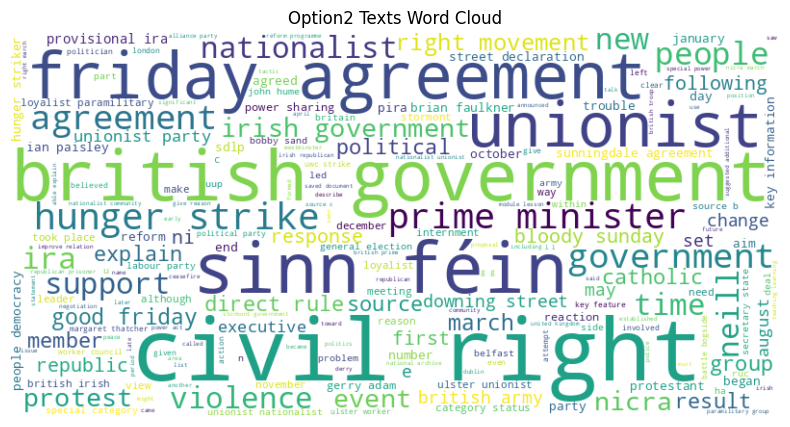

In [5]:
# Option2 word cloud
wc_option2 = WordCloud(width=800, height=400, background_color='white').generate(option2_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option2, interpolation='bilinear')
plt.axis('off')
plt.title('Option2 Texts Word Cloud')
plt.show()

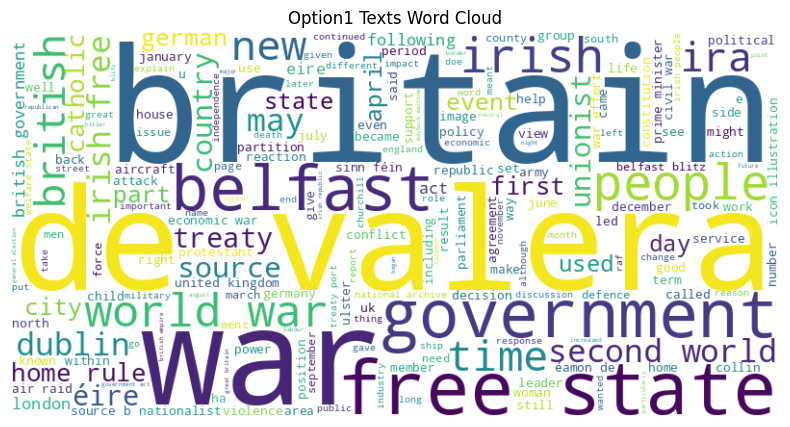

In [6]:
# Option1 word cloud
wc_option1 = WordCloud(width=800, height=400, background_color='white').generate(option1_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option1, interpolation='bilinear')
plt.axis('off')
plt.title('Option1 Texts Word Cloud')
plt.show()

# TFIDF

In [7]:
# Debug: Check what's in the texts
print("\n=== DEBUG INFO ===")
if len(option2_text) > 0:
    print(f"Option2 text sample: {option2_text[:200]}")
    print(f"Option2 text length: {len(option2_text)}")
else:
    print("No Option2 text found!")

if len(option1_text) > 0:
    print(f"Option1 text sample: {option1_text[:200]}")
    print(f"Option1 text length: {len(option1_text)}")
else:
    print("No Option1 text found!")


=== DEBUG INFO ===
Option2 text sample: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted new arrangement unionist mostly protestant delighted
Option2 text length: 1436218
Option1 text sample: madden mcbride ccea gcse chapter page peace war neutrality britain second world war unit relation second world war background partition introduction saw significant change relationship britain british
Option1 text length: 1078374


In [8]:
# Function to get top TF-IDF weighted n-grams
def get_top_tfidf_ngrams(text, ngram_range=(1, 1), top_n=20):
    """Get top n-grams based on TF-IDF scores"""
    
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    
    # Debug: check if we have any content
    print(f"Text length: {len(text)}")
    print(f"First 200 characters: {text[:200]}")
    
    # Check if text is mostly whitespace or empty
    if len(text.strip()) == 0:
        print("Warning: Text is empty or only whitespace!")
        return []
    
    try:
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        print(f"Number of features found: {len(feature_names)}")
        if len(feature_names) > 0:
            print(f"First 10 features: {feature_names[:10]}")
        
        if len(feature_names) == 0:
            print("Warning: No features found. Trying without stopwords...")
            vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            print(f"Features without stopwords: {len(feature_names)}")
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams
        
    except ValueError as e:
        print(f"Error in TF-IDF processing: {e}")
        print("Trying without any stopwords...")
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams

In [9]:
# Analyze Option2 texts
print("\n=== OPTION2 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option2 texts...")
option2_top_terms = get_top_tfidf_ngrams(option2_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Option2 texts:")
for term, score in option2_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option2_top_bigrams = get_top_tfidf_ngrams(option2_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Option2 texts:")
for bigram, score in option2_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== OPTION2 TEXTS ANALYSIS ===
Building TF-IDF for Option2 texts...
Text length: 1436218
First 200 characters: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted new arrangement unionist mostly protestant delighted
Number of features found: 1000
First 10 features: ['able' 'accept' 'accepted' 'accessibility' 'account' 'achieve' 'achieved'
 'achieving' 'across' 'act']

Top 20 terms in Option2 texts:
government: 0.2770
unionist: 0.2495
agreement: 0.2384
british: 0.1948
ira: 0.1567
nationalist: 0.1561
party: 0.1421
irish: 0.1364
right: 0.1354
people: 0.1313
strike: 0.1220
violence: 0.1203
new: 0.1194
march: 0.1181
source: 0.1167
political: 0.1130
civil: 0.1111
support: 0.1108
may: 0.1024
catholic: 0.1006
Text length: 1436218
First 200 characters: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted n

In [10]:
# Analyze Option1 texts
print("\n=== OPTION1 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option1 texts...")
option1_top_terms = get_top_tfidf_ngrams(option1_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Option1 texts:")
for term, score in option1_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option1_top_bigrams = get_top_tfidf_ngrams(option1_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Option1 texts:")
for bigram, score in option1_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== OPTION1 TEXTS ANALYSIS ===
Building TF-IDF for Option1 texts...
Text length: 1078374
First 200 characters: madden mcbride ccea gcse chapter page peace war neutrality britain second world war unit relation second world war background partition introduction saw significant change relationship britain british
Number of features found: 1000
First 10 features: ['able' 'academy' 'accept' 'accepted' 'access' 'accessibility' 'according'
 'account' 'across' 'act']

Top 20 terms in Option1 texts:
war: 0.3654
irish: 0.3621
government: 0.2112
britain: 0.2064
british: 0.2007
state: 0.1836
belfast: 0.1518
people: 0.1467
de: 0.1380
valera: 0.1358
source: 0.1221
free: 0.1203
world: 0.1056
treaty: 0.1008
home: 0.0953
new: 0.0941
time: 0.0915
ira: 0.0844
dublin: 0.0804
act: 0.0800
Text length: 1078374
First 200 characters: madden mcbride ccea gcse chapter page peace war neutrality britain second world war unit relation second world war background partition introduction saw significant change relati